In [1]:
import os
import sys
import torch
import importlib
import pandas as pd
from sklearn.linear_model import Ridge

import utils
import matplotlib.pyplot as plt
import evaluation_metrics as em
from datasets import load_dataset
from hkan import swim_sampling as ss
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable
)

importlib.reload(utils)

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from '/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py'>

# TF1 Experiments

## HKAN

In [2]:
# Load TF1 dataset
tf1 = load_dataset("TF1")
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = tf1["train_input"], tf1["test_input"], tf1["train_label"], tf1["test_label"]

In [3]:
print("TF1 train describe")
display(pd.DataFrame(tf1_x_train).describe())
print("TF1 test describe")
display(pd.DataFrame(tf1_x_test).describe())
print("TF1 y_train describe")
display(pd.Series(tf1_y_train).describe())
print("TF1 y_test describe")
display(pd.Series(tf1_y_test).describe())

TF1 train describe


,0,1
count,5000.000000,5000.000000
mean,0.502492,0.498871
std,0.291808,0.285606
min,0.000021,0.000020
25%,0.247467,0.253435
50%,0.504131,0.497807
75%,0.758499,0.743126
max,0.999705,0.999692


TF1 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250000,0.250000
50%,0.500000,0.500000
75%,0.750000,0.750000
max,1.000000,1.000000


TF1 y_train describe


count    5000.000000
mean        0.505381
std         0.166339
min         0.009263
25%         0.414095
50%         0.501150
75%         0.600623
max         0.988818
dtype: float64

TF1 y_test describe


count    10000.000000
mean         0.500000
std          0.170042
min          0.000000
25%          0.404882
50%          0.500000
75%          0.595118
max          1.000000
dtype: float64

In [4]:
def create_and_evaluate_hkan_model(params, X_train, X_test, y_train, y_test, title):
    model = utils.build_hkan_from_params(params)
    utils.fit_hkan(model,  X_train, y_train)
    results = em.evaluate(
        model,
        X_train, y_train, X_test, y_test
    )
    em.print_results(results)
    y_test_pred = utils.predict_hkan(model, X_test)
    utils.plot_3d_surface(title, X_test, y_test, y_test_pred)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.78it/s]



✓ HKAN training completed in 3.9170 seconds
Metric          Train                Test                
-------------------------------------------------------
MAE             3.214399e-12         3.602555e-12        
RMSE            4.184388e-12         5.492100e-12        
✓ HKAN prediction completed in 2.2591 seconds
✓ Figure saved to results/TF1 Random_3d_surface.png


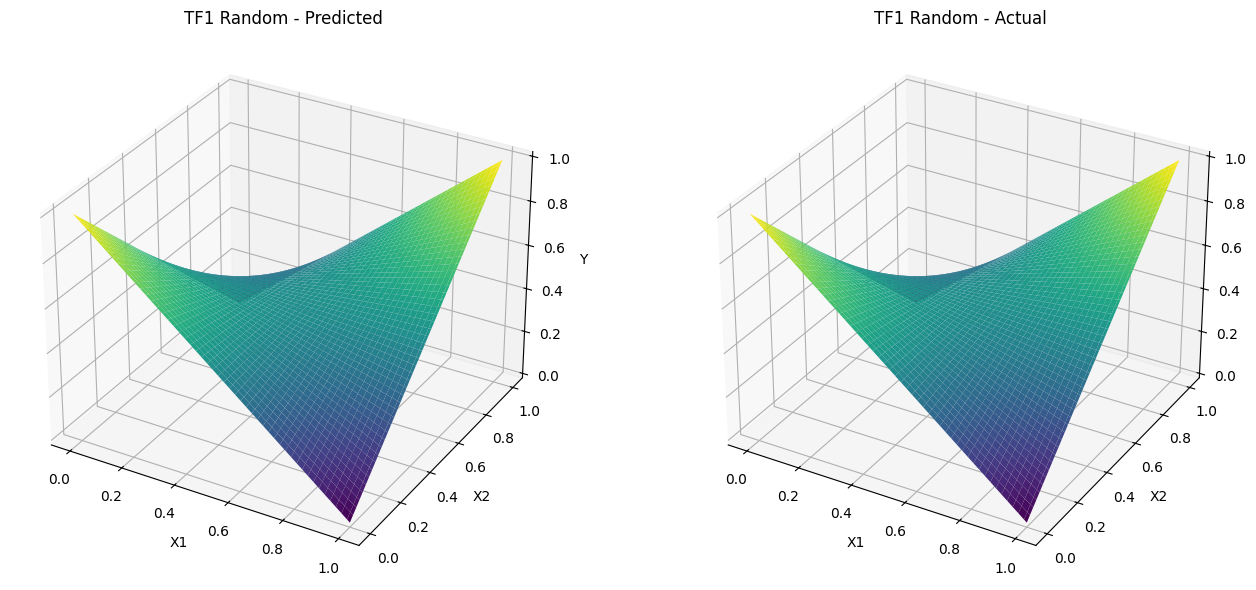

In [5]:
tf1_random_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random",
        "regressor": Ridge(alpha=10),
    }
]
create_and_evaluate_hkan_model(tf1_random_params, tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test, "TF1 Random")

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.40it/s]



✓ HKAN training completed in 4.9688 seconds
Metric          Train                Test                
-------------------------------------------------------
MAE             1.369597e-11         1.570914e-11        
RMSE            1.846447e-11         2.519180e-11        
✓ HKAN prediction completed in 2.6040 seconds
✓ Figure saved to results/TF1 Optuna_3d_surface.png


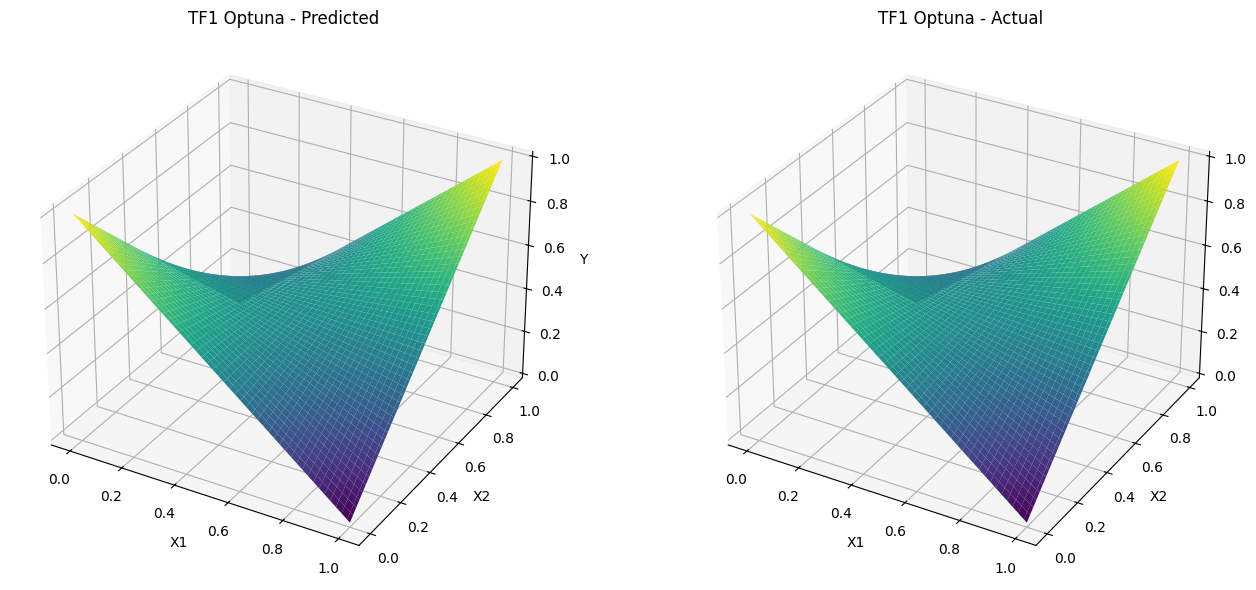

In [6]:
tf1_optuna_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=10),
    }
]
create_and_evaluate_hkan_model(tf1_optuna_params, tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test, "TF1 Optuna")

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.66it/s]



✓ HKAN training completed in 4.6975 seconds
Metric          Train                Test                
-------------------------------------------------------
MAE             1.083832e-11         1.226721e-11        
RMSE            1.428749e-11         1.933810e-11        
✓ HKAN prediction completed in 2.7432 seconds
✓ Figure saved to results/TF1 Edge SWIM_3d_surface.png


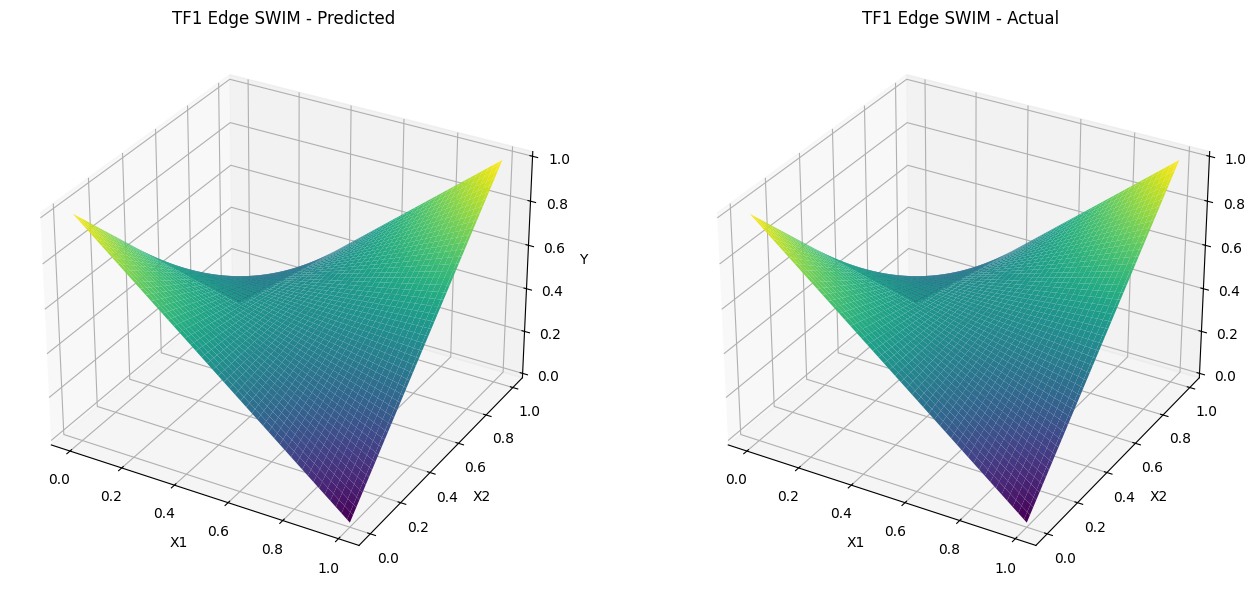

In [11]:
tf1_sigma_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "edge_isolated_swim_centers",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "edge_isolated_swim_centers",
        "regressor": Ridge(alpha=10),
    }
]
create_and_evaluate_hkan_model(tf1_sigma_params, tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test, "TF1 Edge SWIM")

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]



✓ HKAN training completed in 4.6077 seconds
Metric          Train                Test                
-------------------------------------------------------
MAE             2.279532e-11         2.550048e-11        
RMSE            3.046314e-11         3.894175e-11        
✓ HKAN prediction completed in 2.9065 seconds
✓ Figure saved to results/TF1 Neuron SWIM_3d_surface.png


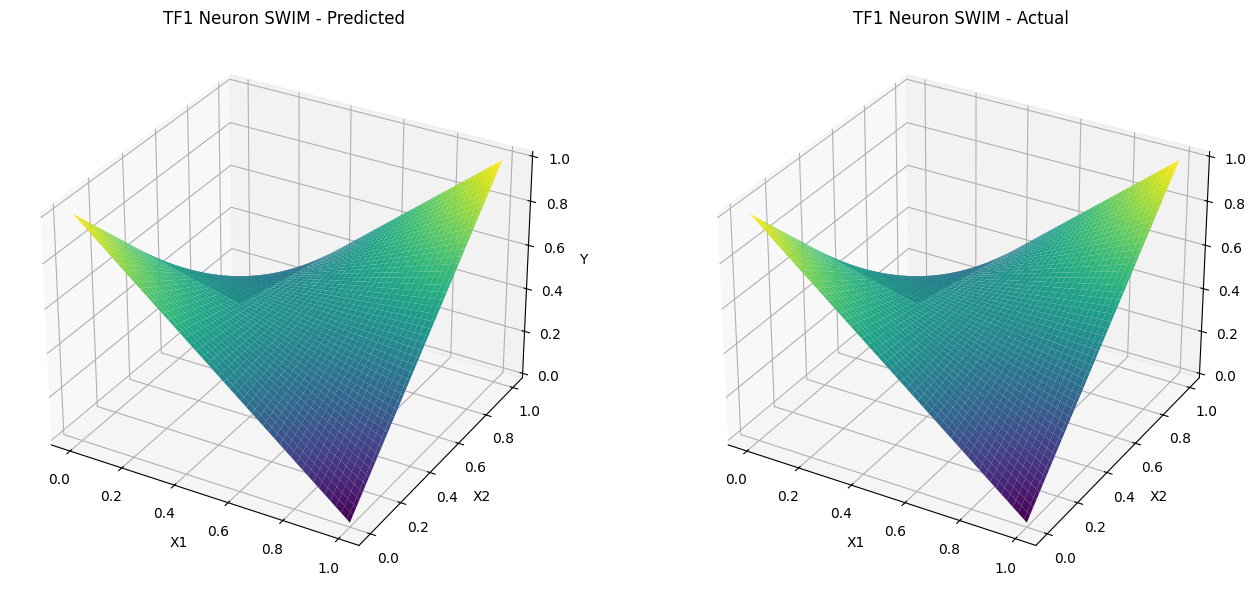

In [9]:
# TF1 SWIM model params
tf1_neuron_swim_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "neuron_shared_swim_centers",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "neuron_shared_swim_centers",
        "regressor": Ridge(alpha=10),
    }
]
create_and_evaluate_hkan_model(tf1_neuron_swim_params, tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test, "TF1 Neuron SWIM")

# TF2 Experiments

## HKAN

In [ ]:
# Load TF2 dataset
tf2 = load_dataset("TF2")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = tf2["train_input"], tf2["test_input"], tf2["train_label"], tf2["test_label"]

In [ ]:
print("TF2 train describe")
display(pd.DataFrame(tf2_x_train).describe())
print("TF2 test describe")
display(pd.DataFrame(tf2_x_test).describe())
print("TF2 y_train describe")
display(pd.Series(tf2_y_train).describe())
print("TF2 y_test describe")
display(pd.Series(tf2_y_test).describe())

In [ ]:
# TF2 random model params
tf2_random_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "random",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "random",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "random",
        "regressor": Ridge(),
    }
]
create_and_evaluate_hkan_model(tf2_random_params, tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test, "TF2 Random")

In [ ]:
# TF2 Optuna model params
tf2_optuna_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "random",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "random",
        "regressor": Ridge(),
    }
]
create_and_evaluate_hkan_model(tf2_optuna_params, tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test, "TF2 Optuna")

In [ ]:
# TF2 Optuna model params
tf2_edge_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "edge_isolated_swim_centers",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "edge_isolated_swim_centers",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "edge_isolated_swim_centers",
        "regressor": Ridge(),
    }
]
create_and_evaluate_hkan_model(tf2_edge_params, tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test, "TF2 Edge SWIM")

In [ ]:
# TF2 Optuna model params
tf2_neuron_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "neuron_shared_swim_centers",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "neuron_shared_swim_centers",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "neuron_shared_swim_centers",
        "regressor": Ridge(),
    }
]
create_and_evaluate_hkan_model(tf2_neuron_params, tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test, "TF2 Neuron SWIM")

# TF3 Experiments

## HKAN

In [ ]:
# Load TF3 dataset
tf3 = load_dataset("TF3")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = tf3["train_input"], tf3["test_input"], tf3["train_label"], tf3["test_label"]

In [ ]:
print("TF3 train describe")
display(pd.DataFrame(tf3_x_train).describe())
print("TF3 test describe")
display(pd.DataFrame(tf3_x_test).describe())
print("TF3 y_train describe")
display(pd.Series(tf3_y_train).describe())
print("TF3 y_test describe")
display(pd.Series(tf3_y_test).describe())

In [ ]:
# TF3 HKAN model params
tf3_optuna_params = [
    {
        "layer": 0,
        "n_vars_out": 924,
        "basis_fn": Tanh(s=50),
        "n_basis": 39,
        "centers": "random",
        "regressor": Ridge(alpha=0.001),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random",
        "regressor": Ridge(),
    }
]
create_and_evaluate_hkan_model(tf3_optuna_params, tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test, "TF3 Optuna")

In [ ]:
# TF3 edge model params
tf3_edge_params = [
    {
        "layer": 0,
        "n_vars_out": 924,
        "basis_fn": Tanh(s=50),
        "n_basis": 39,
        "centers": "edge_isolated_swim_centers",
        "regressor": Ridge(alpha=0.001),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "edge_isolated_swim_centers",
        "regressor": Ridge(),
    }
]
create_and_evaluate_hkan_model(tf3_edge_params, tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test, "TF3 Edge SWIM")

In [ ]:
# TF3 neuron model params
tf3_neuron_params = [
    {
        "layer": 0,
        "n_vars_out": 300,
        "basis_fn": Tanh(s=20),
        "n_basis": 39,
        "centers": "neuron_shared_swim_centers",
        "regressor": Ridge(alpha=0.001),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "neuron_shared_swim_centers",
        "regressor": Ridge(),
    }
]
create_and_evaluate_hkan_model(tf3_neuron_params, tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test, "TF3 Neuron SWIM")